In [21]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
from jax import value_and_grad, vmap

# Plotting
import matplotlib.pyplot as plt
import matplotlib as mpl

# Differentiable Particle Filtering with Non-Gaussian Emissions

Differentiable particle filters offer a methodology for non-Gaussian emissions, even with multi-modal belief distributions.

In [22]:
# CD-NLGSSM imports
from cd_dynamax import ContDiscreteNonlinearSSM, ContDiscreteNonlinearGaussianSSM
from cd_dynamax.src.utils.experiment_utils import *
from cd_dynamax.src.utils.data_generator import *

## Differentiable particle filtering with Poisson emissions

To illustrate the usefulness of the differentiable particle filter, we will perform filtering on a state spoce model with non-Gaussian observations.

In particular, we simulate a 1D continuous-time SDE (Ornstein-Uhlenbeck process), then generate Poisson counts via an exponential link function. 


### Model and Simulated Data

Latent dynamics (1D OU SDE):

$$ d x(t) = \kappa (\mu - x(t)) \, dt + \sigma \, dW(t) $$

Observation model (binned Poisson process counts):

$$ y_k \mid x_k \sim \text{Poisson}(\Delta t \cdot \exp(x_k + b)) $$

We’ll sample the latent path and Poisson emissions directly from the CD-NLSSM (non-Gaussian emissions) using its path sampler.



### The CD-NLSSM model defintion

In [23]:
# CD-NLSSM model definition: scalar state and emission
state_dim=1
emission_dim=1

In [24]:
# Initial state distribution: Gaussian
from cd_dynamax.src.continuous_discrete_nonlinear_ssm.cdnlssm_utils import StaticGaussianDistribution
initial_sd = 0.5
initial_distribution = {
    "params": StaticGaussianDistribution(
        mean=jnp.zeros(state_dim),
        cov=(initial_sd**2) * jnp.eye(state_dim)
    ),
    "props": None,
}

In [25]:
# Dynamics based on OU drift
# Learnable drift function for OU process
class LearnableOU_Drift(NamedTuple):
    kappa: Union[Float[Array, "1"], ParameterProperties]
    mu: Union[Float[Array, "1"], ParameterProperties]

    def f(self, x, u=None, t=None):
        return self.kappa * (self.mu - x)
    
    def get_params(self):
        return _get_params(self.kappa, self.mu)

In [26]:
# Emission: Poisson distributed
from cd_dynamax.src.continuous_discrete_nonlinear_ssm.cdnlssm_utils import LearnablePoissonEmission
# Time grid: critical for emissions, as the Poisson rate depends on dt
dt = 0.1
poisson_emission = LearnablePoissonEmission(
    dt=float(dt),
    bias=jnp.log(50.0)
)

In [27]:
# Define de CD-NLSSM
true_cdnlssm = ContDiscreteNonlinearSSM(
        state_dim=1,
        emission_dim=1
)

### Data: sampling from an specific CD-NLSSM

In [28]:
# Define the emission times (shape (T, 1))
T = 1_000
t_emissions = (jnp.arange(T) * dt).reshape(-1, 1)

# Initialize with dynamics and emission of choice
# True latent dynamics parameters
true_kappa = 0.8
true_mu = 0.0
true_sigma = 0.4   

In [29]:
# Initialize the CD-NLSSM with the specified initial distribution, dynamics, and emission
true_params, true_props= true_cdnlssm.initialize(
        initial_distribution=initial_distribution,
        dynamics_drift={
            "params": LearnableOU_Drift(kappa=true_kappa, mu=true_mu),
            "props": None,  # Let us use the default parameter properties
        },
        dynamics_diffusion_coefficient={
            "params": LearnableMatrix(params=true_sigma * jnp.eye(state_dim)),
            "props": LearnableMatrix(params=ParameterProperties(trainable=False))
        },
        emission_distribution={
            "params": poisson_emission,
            "props": None,  # Let us use the default parameter properties
        },
    )

In [30]:
# Simulate data
states, emissions = true_cdnlssm.sample(
    params=true_params,
    key=jr.PRNGKey(0),
    num_timesteps=T,
    t_emissions=t_emissions,
    transition_type="path",
)

Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.


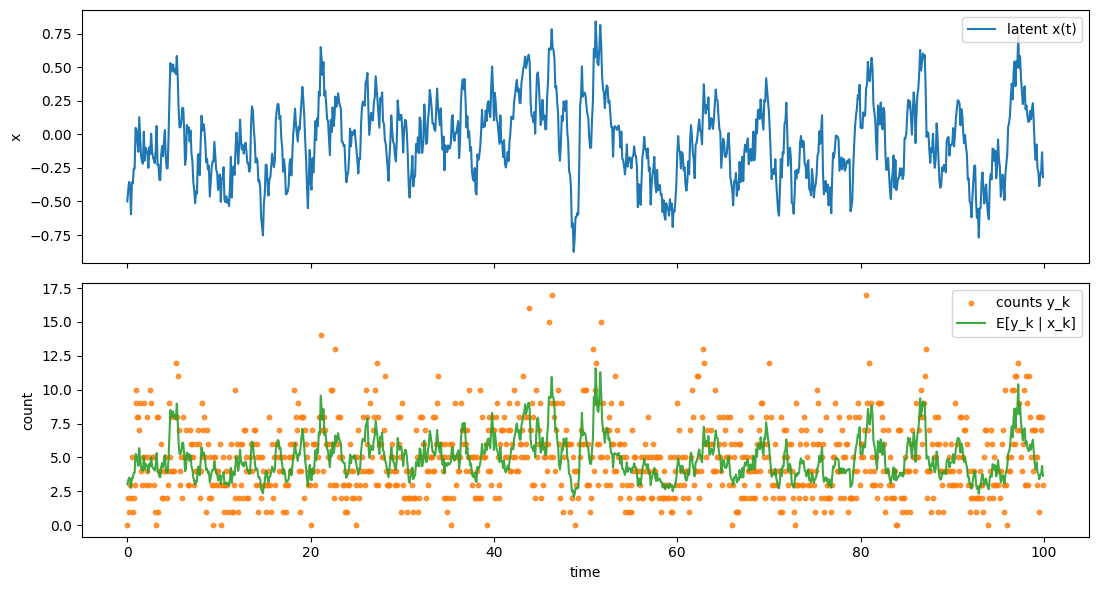

In [31]:
# Plot latent state + Poisson counts
t = t_emissions.squeeze()

# Compute the Poisson rates for plotting
true_bias = poisson_emission.bias
rates = dt * jnp.exp(states[:, 0] + true_bias)

# Plotting
fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axs[0].plot(t, states[:, 0], color="C0", label="latent x(t)")
axs[0].set_ylabel("x")
axs[0].legend(loc="upper right")

axs[1].scatter(t, emissions[:, 0], s=10, color="C1", alpha=0.8, label="counts y_k")
axs[1].plot(t, rates, color="C2", alpha=0.9, label="E[y_k | x_k]")
axs[1].set_ylabel("count")
axs[1].set_xlabel("time")
axs[1].legend(loc="upper right")

plt.tight_layout()

### Filtering: Seamless inference, using a Differentiable Particle Filter

In [32]:
filtered = true_cdnlssm.filter(
    params=true_params,
    emissions=emissions,
    t_emissions=t_emissions,
    key=jr.PRNGKey(1),
    N_particles=1_000,
    warn=False,
)

print("DPF marginal log-likelihood:", float(filtered.marginal_loglik))

DPF marginal log-likelihood: -2301.893614468046


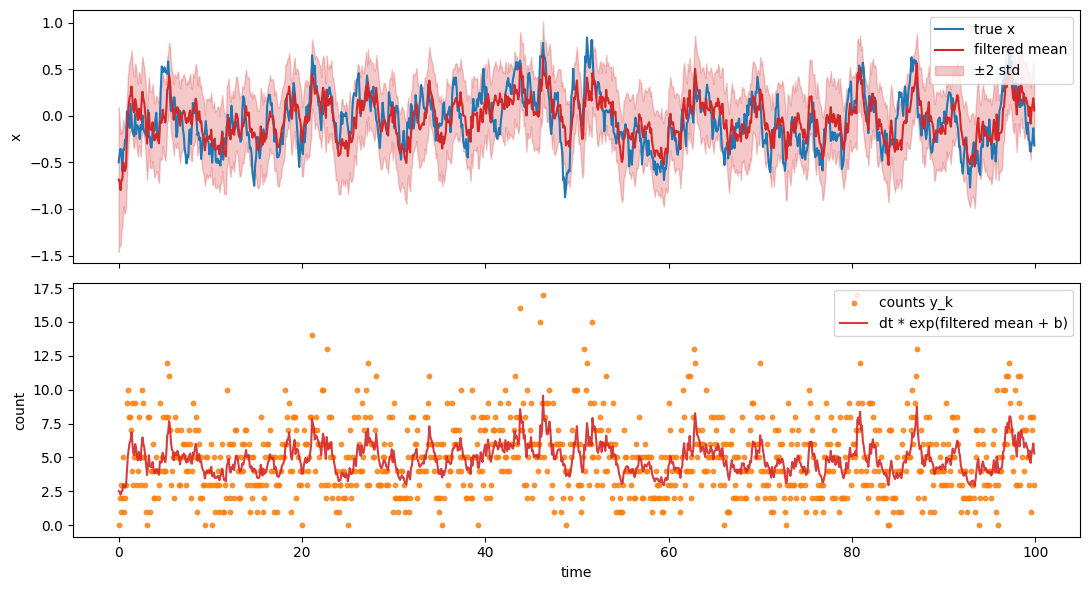

In [33]:
# Plot filtered state estimate (mean +/- 2 std) and compare against truth
t = t_emissions.squeeze()
m = filtered.filtered_means[:, 0]
s = jnp.sqrt(filtered.filtered_covariances[:, 0, 0])

fig, axs = plt.subplots(2, 1, figsize=(11, 6), sharex=True)

axs[0].plot(t, states[:, 0], color="C0", label="true x")
axs[0].plot(t, m, color="C3", label="filtered mean")
axs[0].fill_between(t, m - 2 * s, m + 2 * s, color="C3", alpha=0.25, label="±2 std")
axs[0].set_ylabel("x")
axs[0].legend(loc="upper right")

pred_counts = dt * jnp.exp(m + true_bias)
axs[1].scatter(t, emissions[:, 0], s=10, color="C1", alpha=0.8, label="counts y_k")
axs[1].plot(t, pred_counts, color="C3", alpha=0.9, label="dt * exp(filtered mean + b)")
axs[1].set_ylabel("count")
axs[1].set_xlabel("time")
axs[1].legend(loc="upper right")

plt.tight_layout()

### Marginal log-likelihood and differentiability



In [34]:
# We can build DPF hyperparameters, with defaults and flexibility to specify different values for different runs.
from cd_dynamax.src.continuous_discrete_nonlinear_ssm.inference_dpf import DPFHyperParams, build_dpf_hyperparams

# For instance, we move forward with a DPF with N_particles=500
dpf_hyperparams = build_dpf_hyperparams(
    filter_state_order = "first",
    filter_state_cov_rescaling = 1.0,
    filter_dt_average = 0.1,
    N_particles = 500,
    diffeqsolve_dt0 = 1e-2,
    diffeqsolve_max_steps = 100,
)

In [35]:
# Define a function that computes the DPF log-likelihood for a given bias value, keeping all other parameters fixed.
def dpf_loglik_for_bias(bias):
    # Define new emission with the specified bias
    poisson_emission = LearnablePoissonEmission(
        dt=float(dt),
        bias=bias
    )
    
    # Re-initialize the CD-NLSSM with the new emission bias (keeping dynamics the same)
    params, _= true_cdnlssm.initialize(
        initial_distribution=initial_distribution,
        dynamics_drift={
            "params": LearnableOU_Drift(kappa=true_kappa, mu=true_mu),
            "props": None,  # Let us use the default parameter properties
        },
        dynamics_diffusion_coefficient={
            "params": LearnableMatrix(params=true_sigma * jnp.eye(state_dim)),
            "props": LearnableMatrix(params=ParameterProperties(trainable=False))
        },
        emission_distribution={
            "params": poisson_emission,
            "props": None,  # Let us use the default parameter properties
        },
    )

    # Compute the DPF log-likelihood for this bias value
    return true_cdnlssm.marginal_log_prob(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        filter_hyperparams=dpf_hyperparams,
        key=jr.PRNGKey(2),
        warn=False,
    )

In [36]:
# Bias grid around the true bias value, to evaluate the log-likelihood and its gradient
bias_grid = jnp.linspace(true_bias - 1.0, true_bias + 1.0, 31)

# Compute marginal log-likelihood and its gradient across the bias grid
val_and_grad = value_and_grad(dpf_loglik_for_bias)
vals, grads = vmap(val_and_grad)(bias_grid)

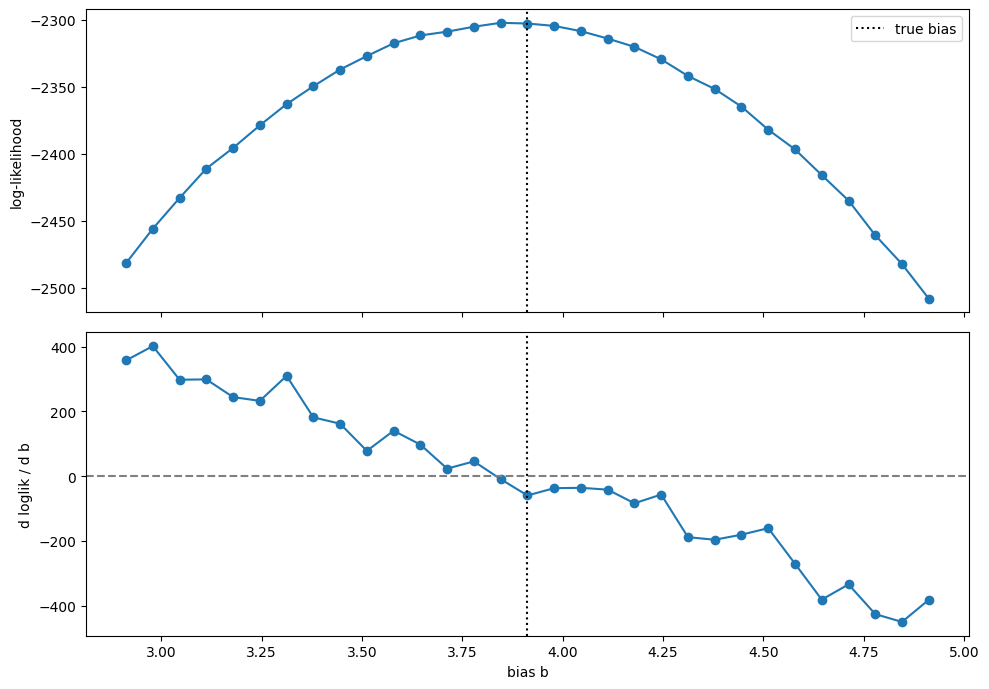

In [37]:
# Plot the log-likelihood and its gradient as a function of the bias parameter,
# and check that the maximum is close to the true bias value.
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(bias_grid, vals, marker="o")
axs[0].axvline(true_bias, color="k", linestyle=":", label="true bias")
axs[0].set_ylabel("log-likelihood")
axs[0].legend(loc="best")

axs[1].plot(bias_grid, grads, marker="o")
axs[1].axhline(0.0, color="gray", linestyle="--")
axs[1].axvline(true_bias, color="k", linestyle=":")
axs[1].set_xlabel("bias b")
axs[1].set_ylabel("d loglik / d b")

plt.tight_layout()

In [38]:
# Define a function that computes the DPF log-likelihood for a given bias value, keeping all other parameters fixed.
def dpf_loglik_for_kappa(kappa):    
    # Re-initialize the CD-NLSSM with dynamics drift with the specified kappa (keeping emission the same)
    params, _= true_cdnlssm.initialize(
        initial_distribution=initial_distribution,
        dynamics_drift={
            "params": LearnableOU_Drift(kappa=kappa, mu=true_mu),
            "props": None,  # Let us use the default parameter properties
        },
        dynamics_diffusion_coefficient={
            "params": LearnableMatrix(params=true_sigma * jnp.eye(state_dim)),
            "props": LearnableMatrix(params=ParameterProperties(trainable=False))
        },
        emission_distribution={
            "params": LearnablePoissonEmission(
                dt=float(dt),
                bias=true_bias
        ),
            "props": None,  # Let us use the default parameter properties
        },
    )

    # Compute the DPF log-likelihood for this kappa value
    return true_cdnlssm.marginal_log_prob(
        params=params,
        emissions=emissions,
        t_emissions=t_emissions,
        filter_hyperparams=dpf_hyperparams,
        key=jr.PRNGKey(2),
        warn=False,
    )

In [39]:
# Kappa grid around the true kappa value, to evaluate the log-likelihood and its gradient
kappa_grid = jnp.linspace(true_kappa - 0.5, true_kappa + 0.5, 31)

# Compute marginal log-likelihood and its gradient across the kappa grid
val_and_grad_kappa = value_and_grad(dpf_loglik_for_kappa)
vals_kappa, grads_kappa = vmap(val_and_grad_kappa)(kappa_grid)

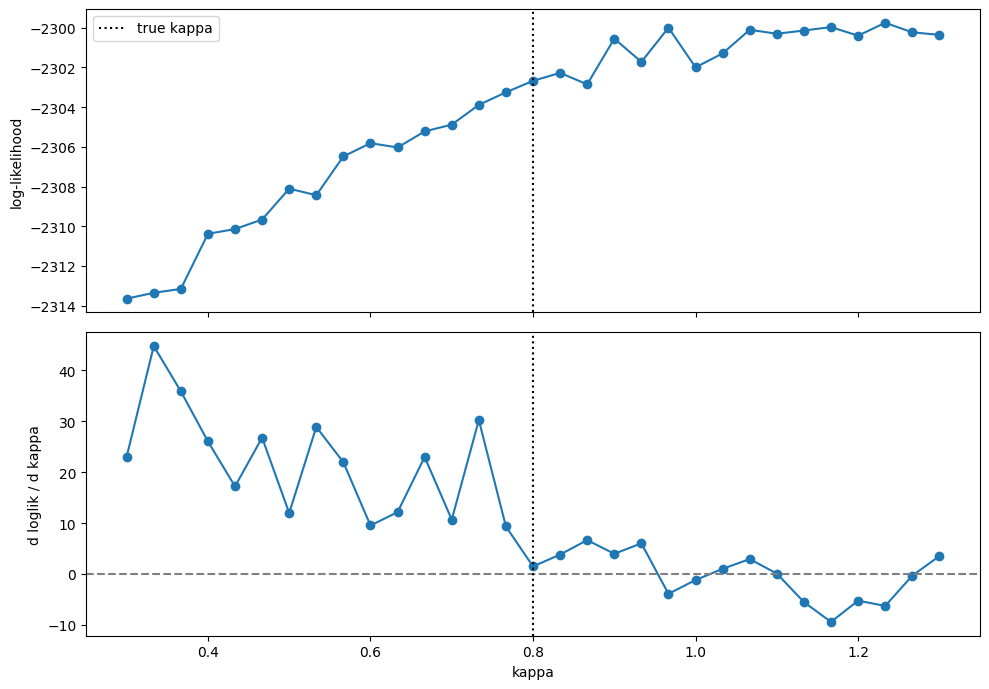

In [40]:
fig, axs = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

axs[0].plot(kappa_grid, vals_kappa, marker="o")
axs[0].axvline(true_kappa, color="k", linestyle=":", label="true kappa")
axs[0].set_ylabel("log-likelihood")
axs[0].legend(loc="best")

axs[1].plot(kappa_grid, grads_kappa, marker="o")
axs[1].axhline(0.0, color="gray", linestyle="--")
axs[1].axvline(true_kappa, color="k", linestyle=":")
axs[1].set_xlabel("kappa")
axs[1].set_ylabel("d loglik / d kappa")

plt.tight_layout()